# Tutorial de ponta a ponta em Mineração de Processos

Este tutorial percorre o ciclo completo de uma análise de mineração de processos, reaproveitando o **mesmo log de eventos sintético** usado no `01-variant-pareto` (um processo de atendimento de pedidos com recebimento, verificação, esclarecimento, aprovação, rejeição, embalagem, retrabalho e envio).

Percurso do tutorial:

1. Carregar o log de eventos e traduzi-lo para PT-BR.
2. Estatísticas descritivas sobre eventos, casos, atividades e traces.
3. Variantes de processo: um exemplo Pareto e um exemplo dominado (não-Pareto).
4. Descoberta de processo: grafo diretamente-seguido (DFG).
5. Redes de Petri com os algoritmos **Alpha**, **Heurística** e **Indutivo**, com métricas de qualidade.
6. Seleção do modelo mais adequado à finalidade da análise.
7. Profiling + encoding de fluxo de controle com **clusterização** para redescobrir as variantes.
8. Comparação das variantes por meio de DFGs específicos de cada cluster.
9. Aprimoramento de processo (*process enhancement*): gargalos, retrabalho e transferências.
10. Verificação de conformidade contra um modelo de referência.
11. Predição da próxima atividade com a biblioteca **skpm** (https://github.com/raseidi/skpm).

**Observação sobre nomes internos:** para reaproveitar sem duplicar as funções já testadas do `01-variant-pareto/variant_pareto_lab.py` (geração do log, clusterização exata por similaridade de edição e o comparador de Pareto), algumas chamadas usam uma cópia auxiliar do log com os nomes de coluna **originais em inglês** (`eventos_en`). Todo o restante do tutorial — nomes de colunas, nomes de atividades, categorias, comentários e gráficos — está em português.

## 1. Preparação: carregar e traduzir o log de eventos

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Localiza a raiz do repositório e reaproveita o gerador determinístico do Lab 01
raiz = Path.cwd()
while not (raiz / "labs").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

from labs.common import load_variant_lab

lab_variantes = load_variant_lab()
eventos_en = lab_variantes.generate_event_log()  # nomes de coluna originais (inglês), usados só para reaproveitar o Lab 01

# --- Dicionários de tradução (nomes de colunas, atividades e categorias) ---
COLUNAS_PT = {
    "case_id": "id_caso",
    "activity": "atividade",
    "lifecycle": "ciclo_vida",
    "timestamp": "carimbo_tempo",
    "duration_hours": "duracao_horas",
    "channel": "canal",
    "product_type": "tipo_produto",
    "priority": "prioridade",
    "amount": "valor",
    "customer_note": "observacao_cliente",
    "path_name": "caminho",
    "late_period": "periodo_tardio",
    "outcome": "resultado",
}

ATIVIDADE_PT = {
    "Receive": "Receber",
    "Check": "Verificar",
    "Clarify": "Esclarecer",
    "Approve": "Aprovar",
    "Reject": "Rejeitar",
    "Pack": "Embalar",
    "Rework": "Retrabalhar",
    "Ship": "Enviar",
}
CICLO_VIDA_PT = {"start": "início", "complete": "concluído", "suspend": "suspenso", "resume": "retomado"}
CANAL_PT = {"web": "web", "partner": "parceiro", "direct": "direto"}
TIPO_PRODUTO_PT = {"standard": "padrão", "custom": "personalizado", "service": "serviço"}
PRIORIDADE_PT = {"normal": "normal", "high": "alta"}
RESULTADO_PT = {"good": "bom", "adverse": "adverso"}
CAMINHO_PT = {
    "normal": "normal",
    "clarify": "esclarecimento",
    "reject": "rejeição",
    "expedite": "expresso",
    "rework": "retrabalho",
}


def traduzir_log(eventos: pd.DataFrame) -> pd.DataFrame:
    """Traduz colunas e valores categóricos do log de eventos para PT-BR (cópia, não altera o original)."""
    traduzido = eventos.rename(columns=COLUNAS_PT).copy()
    traduzido["atividade"] = traduzido["atividade"].map(ATIVIDADE_PT)
    traduzido["ciclo_vida"] = traduzido["ciclo_vida"].map(CICLO_VIDA_PT)
    traduzido["canal"] = traduzido["canal"].map(CANAL_PT)
    traduzido["tipo_produto"] = traduzido["tipo_produto"].map(TIPO_PRODUTO_PT)
    traduzido["prioridade"] = traduzido["prioridade"].map(PRIORIDADE_PT)
    traduzido["resultado"] = traduzido["resultado"].map(RESULTADO_PT)
    traduzido["caminho"] = traduzido["caminho"].map(CAMINHO_PT)
    return traduzido


eventos = traduzir_log(eventos_en)
print(f"Eventos: {len(eventos):,}")
print(f"Casos: {eventos['id_caso'].nunique():,}")
print(f"Atividades distintas: {sorted(eventos['atividade'].unique())}")
eventos.head(10)

Eventos: 2,400
Casos: 240
Atividades distintas: ['Aprovar', 'Embalar', 'Enviar', 'Esclarecer', 'Receber', 'Rejeitar', 'Retrabalhar', 'Verificar']


,id_caso,canal,tipo_produto,prioridade,valor,observacao_cliente,caminho,periodo_tardio,atividade,ciclo_vida,carimbo_tempo,duracao_horas,resultado
0,C-0001,web,padrão,normal,348.431570,standard request,normal,False,Receber,início,2025-01-06 14:45:38.154032579,NaN,NaN
1,C-0001,web,padrão,normal,348.431570,standard request,normal,False,Receber,concluído,2025-01-06 15:03:20.383862896,0.295064,NaN
2,C-0001,web,padrão,normal,348.431570,standard request,normal,False,Verificar,início,2025-01-06 15:32:30.333913849,NaN,NaN
3,C-0001,web,padrão,normal,348.431570,standard request,normal,False,Verificar,concluído,2025-01-06 17:09:18.717450346,1.613440,NaN
4,C-0001,web,padrão,normal,348.431570,standard request,normal,False,Aprovar,início,2025-01-06 17:54:13.350284561,NaN,NaN
5,C-0001,web,padrão,normal,348.431570,standard request,normal,False,Aprovar,concluído,2025-01-06 19:21:15.295655459,1.450540,NaN
6,C-0001,web,padrão,normal,348.431570,standard request,normal,False,Enviar,início,2025-01-06 19:27:43.561313860,NaN,NaN
7,C-0001,web,padrão,normal,348.431570,standard request,normal,False,Enviar,concluído,2025-01-06 22:02:30.007040761,2.579568,adverso
8,C-0002,web,padrão,normal,299.429903,standard request,normal,False,Receber,início,2025-01-07 02:03:19.485490010,NaN,NaN
9,C-0002,web,padrão,normal,299.429903,standard request,normal,False,Receber,concluído,2025-01-07 02:37:44.874626150,0.573719,NaN


## 2. Estatísticas descritivas: eventos, casos, atividades e traces

Antes de descobrir ou avaliar qualquer modelo, vale entender o "formato" básico do log: quantos eventos por caso, quanto tempo cada caso demora, com que frequência cada atividade ocorre, e quais traces (sequências completas) aparecem.

Resumo de casos:
       n_eventos  duracao_caso_horas
count      240.0              240.00
mean         4.7                9.36
std          1.0                5.00
min          3.0                1.94
25%          4.0                5.79
50%          4.0                7.50
75%          6.0               13.32
max          6.0               32.53

Frequência por atividade:
atividade
Verificar      290
Aprovar        249
Receber        240
Enviar         222
Esclarecer      50
Embalar         33
Retrabalhar     27
Rejeitar        18
Name: count, dtype: int64


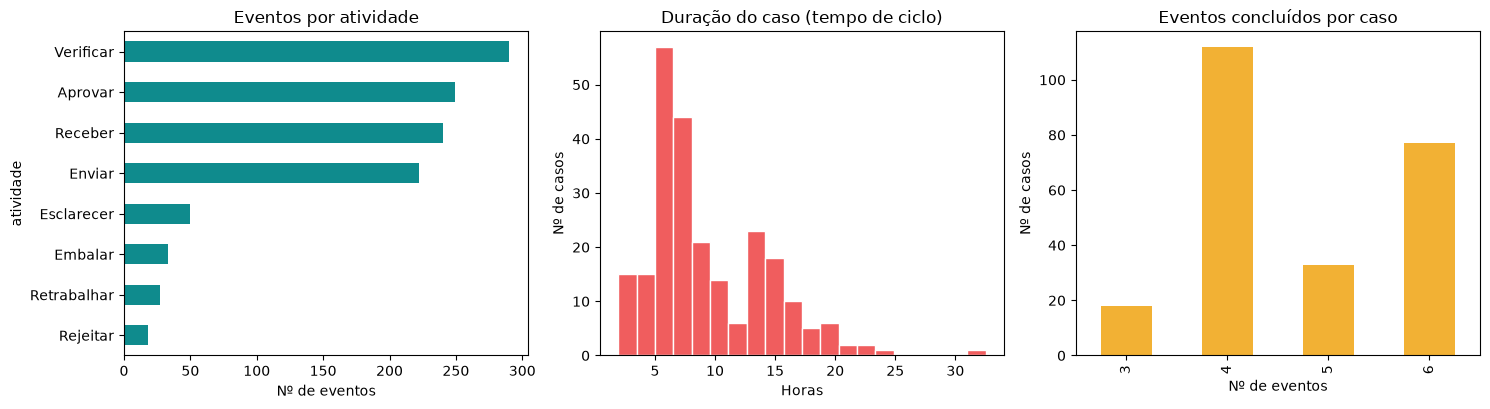

In [2]:
completos = eventos.query("ciclo_vida == 'concluído'").sort_values(["id_caso", "carimbo_tempo"]).copy()

casos = (
    completos.groupby("id_caso")
    .agg(
        inicio=("carimbo_tempo", "min"),
        fim=("carimbo_tempo", "max"),
        n_eventos=("atividade", "size"),
        canal=("canal", "first"),
        caminho=("caminho", "first"),
        resultado=("resultado", "first"),
    )
    .reset_index()
)
casos["duracao_caso_horas"] = (casos["fim"] - casos["inicio"]).dt.total_seconds() / 3600

frequencia_atividade = completos["atividade"].value_counts()

print("Resumo de casos:")
print(casos[["n_eventos", "duracao_caso_horas"]].describe().round(2))
print("\nFrequência por atividade:")
print(frequencia_atividade)

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.2))

frequencia_atividade.sort_values().plot.barh(ax=eixos[0], color="#0F8B8D")
eixos[0].set(title="Eventos por atividade", xlabel="Nº de eventos")

eixos[1].hist(casos["duracao_caso_horas"], bins=20, color="#F05D5E", edgecolor="white")
eixos[1].set(title="Duração do caso (tempo de ciclo)", xlabel="Horas", ylabel="Nº de casos")

casos["n_eventos"].value_counts().sort_index().plot.bar(ax=eixos[2], color="#F2B134")
eixos[2].set(title="Eventos concluídos por caso", xlabel="Nº de eventos", ylabel="Nº de casos")

fig.tight_layout()
plt.show()

### Traces e variantes exatas

Um **trace** é a sequência ordenada de atividades de um caso. Uma **variante** é um padrão de trace compartilhado por vários casos.

Variantes exatas encontradas: 5


,nº de casos
atividade,
Receber → Verificar → Aprovar → Enviar,112
Receber → Verificar → Esclarecer → Verificar → Aprovar → Enviar,50
Receber → Verificar → Aprovar → Embalar → Enviar,33
Receber → Verificar → Aprovar → Retrabalhar → Aprovar → Enviar,27
Receber → Verificar → Rejeitar,18


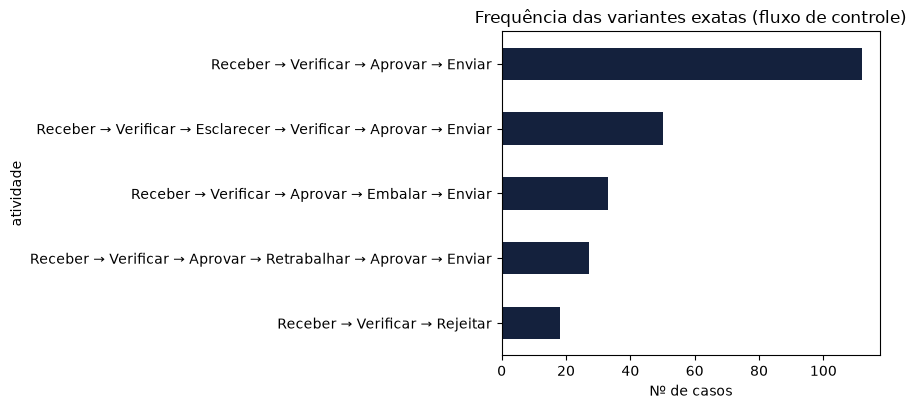

In [3]:
traces = completos.groupby("id_caso")["atividade"].apply(tuple)
traces_formatados = traces.map(lambda trace: " → ".join(trace))
contagem_variantes = traces_formatados.value_counts()

print(f"Variantes exatas encontradas: {contagem_variantes.shape[0]}")
display(contagem_variantes.rename("nº de casos").to_frame())

fig, eixo = plt.subplots(figsize=(9, 4.2))
contagem_variantes.sort_values().plot.barh(ax=eixo, color="#14213D")
eixo.set(title="Frequência das variantes exatas (fluxo de controle)", xlabel="Nº de casos")
fig.tight_layout()
plt.show()

## 3. Variantes: um exemplo Pareto e um exemplo não-Pareto

Reaproveitamos `evaluate_variant_candidates` do Lab 01, que avalia 36 configurações de detecção de variantes (codificação × limiar de similaridade × frequência mínima) em 4 objetivos: cobertura, compactação, relevância decisória e estabilidade temporal. Abaixo comparamos o candidato Pareto de maior escore de evidência com o pior candidato **dominado** (não-Pareto).

,candidato,codificação,cobertura,compactação,relevância_decisória,estabilidade_temporal,escore_evidência,é_pareto
0,lifecycle|sim=0.80|min=1,ciclo de vida,1.000000,0.983264,0.266805,0.869893,0.712233,True
35,payload|sim=1.00|min=20,payload,0.254167,0.995816,0.063554,0.941605,0.419775,False


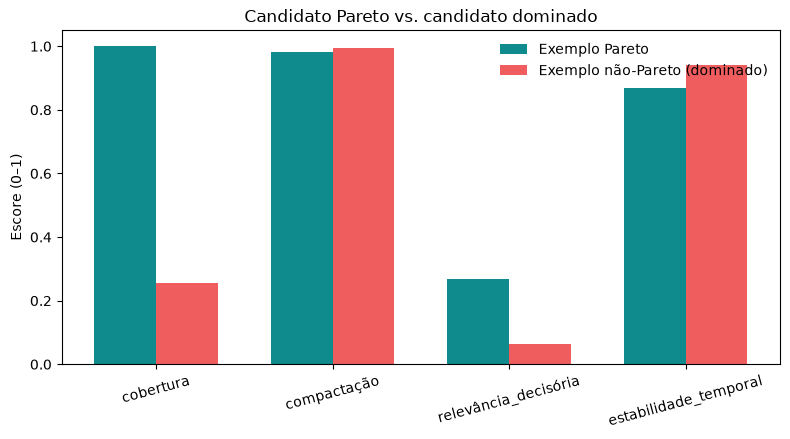

O candidato dominado (payload|sim=1.00|min=20) usa a codificação 'payload' com limiar de similaridade muito estrito, o que fragmenta demais os casos em variantes de caso único, reduzindo a cobertura sem ganho correspondente de relevância decisória — por isso é dominado pelo candidato Pareto.


In [4]:
TRADUCAO_CODIFICACAO = {
    "control_flow": "fluxo de controle",
    "lifecycle": "ciclo de vida",
    "time": "tempo",
    "payload": "payload",
}

candidatos, rotulos_por_candidato = lab_variantes.evaluate_variant_candidates(eventos_en)

exemplo_pareto = candidatos[candidatos["pareto"]].sort_values("evidence_score", ascending=False).iloc[0]
exemplo_nao_pareto = candidatos[~candidatos["pareto"]].sort_values("evidence_score", ascending=True).iloc[0]

colunas_exibicao = ["candidate_id", "encoding", "coverage", "compactness", "decision_relevance", "temporal_stability", "evidence_score", "pareto"]
comparacao = pd.DataFrame([exemplo_pareto[colunas_exibicao], exemplo_nao_pareto[colunas_exibicao]])
comparacao["encoding"] = comparacao["encoding"].map(TRADUCAO_CODIFICACAO)
comparacao = comparacao.rename(
    columns={
        "candidate_id": "candidato",
        "encoding": "codificação",
        "coverage": "cobertura",
        "compactness": "compactação",
        "decision_relevance": "relevância_decisória",
        "temporal_stability": "estabilidade_temporal",
        "evidence_score": "escore_evidência",
        "pareto": "é_pareto",
    }
)
display(comparacao)

fig, eixo = plt.subplots(figsize=(8, 4.5))
metricas = ["cobertura", "compactação", "relevância_decisória", "estabilidade_temporal"]
largura = 0.35
posicoes = np.arange(len(metricas))
eixo.bar(posicoes - largura / 2, comparacao.iloc[0][metricas], largura, label="Exemplo Pareto", color="#0F8B8D")
eixo.bar(posicoes + largura / 2, comparacao.iloc[1][metricas], largura, label="Exemplo não-Pareto (dominado)", color="#F05D5E")
eixo.set_xticks(posicoes)
eixo.set_xticklabels(metricas, rotation=15)
eixo.set(title="Candidato Pareto vs. candidato dominado", ylabel="Escore (0–1)")
eixo.legend(frameon=False)
fig.tight_layout()
plt.show()

print(
    f"O candidato dominado ({exemplo_nao_pareto['candidate_id']}) usa a codificação "
    f"'{TRADUCAO_CODIFICACAO[exemplo_nao_pareto['encoding']]}' com limiar de similaridade muito estrito, "
    "o que fragmenta demais os casos em variantes de caso único, reduzindo a cobertura sem ganho "
    "correspondente de relevância decisória — por isso é dominado pelo candidato Pareto."
)

## 4. Descoberta de processo: grafo diretamente-seguido (DFG)

O DFG resume a adjacência observada entre atividades: nós são atividades, arestas significam "diretamente seguido por", com a contagem de ocorrências.



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Atividades de início: {'Receber': 240}
Atividades de fim: {'Enviar': 222, 'Rejeitar': 18}


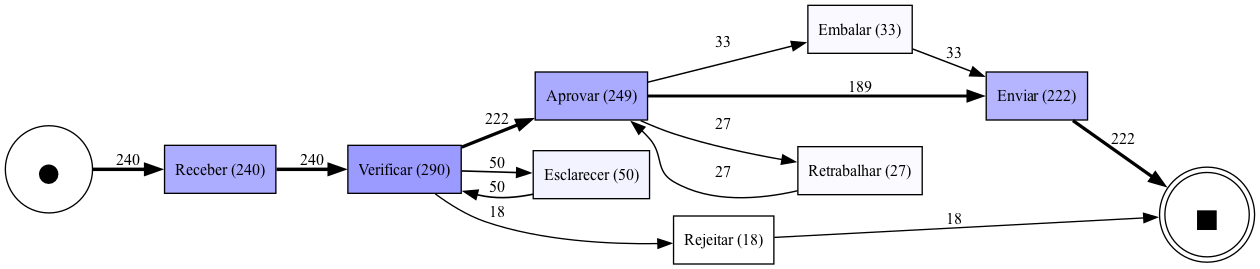

In [5]:
import pm4py
from IPython.display import Image, display

pasta_saida = Path("outputs")
pasta_saida.mkdir(exist_ok=True)

log_pm4py = pm4py.format_dataframe(
    completos.copy(),
    case_id="id_caso",
    activity_key="atividade",
    timestamp_key="carimbo_tempo",
)

dfg_completo, inicios, fins = pm4py.discover_dfg(log_pm4py)
print("Atividades de início:", inicios)
print("Atividades de fim:", fins)

caminho_dfg = pasta_saida / "dfg_completo.png"
pm4py.save_vis_dfg(dfg_completo, inicios, fins, str(caminho_dfg))
display(Image(filename=str(caminho_dfg)))

## 5. Redes de Petri: Alpha, Heurística e Indutivo

Descobrimos três redes de Petri com algoritmos de naturezas diferentes e comparamos **fitness**, **precisão** e **simplicidade** — as mesmas dimensões discutidas na Unidade 7 do curso.

--- Rede de Petri: Alpha ---


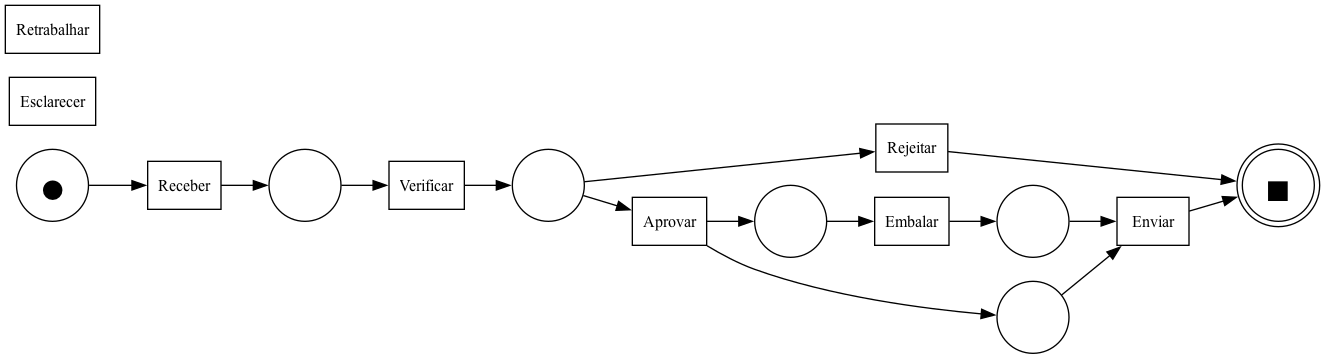

--- Rede de Petri: Heurística ---


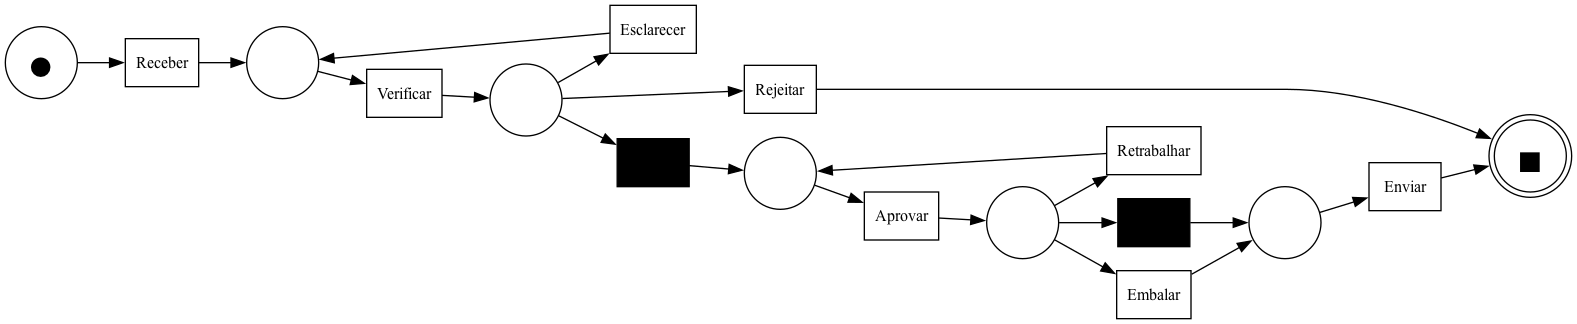

--- Rede de Petri: Indutivo ---


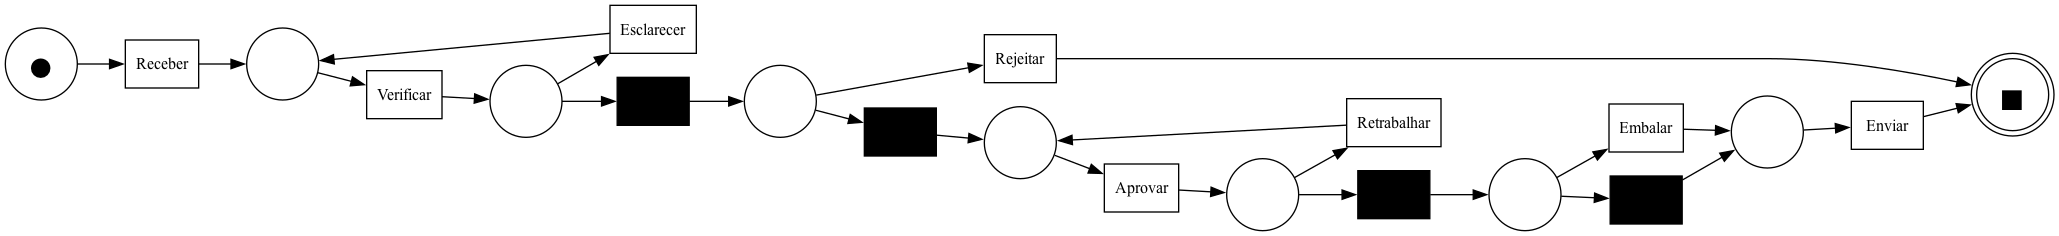

,lugares,transições,fitness,precisão,simplicidade
algoritmo,,,,,
Alpha,7,8,0.817,0.478,1.000
Heurística,7,10,1.000,0.885,0.739
Indutivo,9,12,1.000,0.885,0.778


In [6]:
import pm4py.util.constants

pm4py.util.constants.SHOW_PROGRESS_BAR = False  # oculta a barra de progresso do replay baseado em tokens

algoritmos = {
    "Alpha": pm4py.discover_petri_net_alpha,
    "Heurística": pm4py.discover_petri_net_heuristics,
    "Indutivo": pm4py.discover_petri_net_inductive,
}

metricas_modelos = []
redes_descobertas = {}

for nome, funcao_descoberta in algoritmos.items():
    rede, marcacao_inicial, marcacao_final = funcao_descoberta(log_pm4py)
    redes_descobertas[nome] = (rede, marcacao_inicial, marcacao_final)

    fitness = pm4py.fitness_token_based_replay(log_pm4py, rede, marcacao_inicial, marcacao_final)
    precisao = pm4py.precision_token_based_replay(log_pm4py, rede, marcacao_inicial, marcacao_final)
    simplicidade = pm4py.simplicity_petri_net(rede, marcacao_inicial, marcacao_final)

    metricas_modelos.append(
        {
            "algoritmo": nome,
            "lugares": len(rede.places),
            "transições": len(rede.transitions),
            "fitness": fitness["log_fitness"],
            "precisão": precisao,
            "simplicidade": simplicidade,
        }
    )

    caminho_imagem = pasta_saida / f"petri_{nome.lower()}.png"
    pm4py.save_vis_petri_net(rede, marcacao_inicial, marcacao_final, str(caminho_imagem))
    print(f"--- Rede de Petri: {nome} ---")
    display(Image(filename=str(caminho_imagem)))

tabela_metricas = pd.DataFrame(metricas_modelos).set_index("algoritmo")
display(tabela_metricas.round(3))

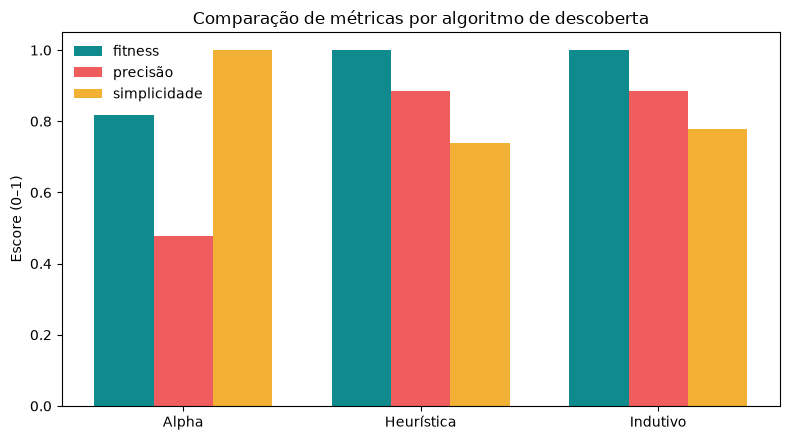

In [7]:
fig, eixo = plt.subplots(figsize=(8, 4.5))
largura = 0.25
posicoes = np.arange(len(tabela_metricas))
cores = {"fitness": "#0F8B8D", "precisão": "#F05D5E", "simplicidade": "#F2B134"}

for deslocamento, (metrica, cor) in zip((-largura, 0, largura), cores.items()):
    eixo.bar(posicoes + deslocamento, tabela_metricas[metrica], largura, label=metrica, color=cor)

eixo.set_xticks(posicoes)
eixo.set_xticklabels(tabela_metricas.index)
eixo.set(title="Comparação de métricas por algoritmo de descoberta", ylabel="Escore (0–1)")
eixo.legend(frameon=False)
fig.tight_layout()
plt.show()

### Seleção do modelo adequado

O **Alpha Miner** tem fitness e precisão visivelmente mais baixos: seu algoritmo clássico de relações de ordenação não lida bem com o laço `Aprovar → Retrabalhar → Aprovar` nem com a repetição de `Verificar` após `Esclarecer`, tratando parte desse comportamento como ruído estrutural. Já **Heurística** e **Indutivo** alcançam fitness de 100% (toda a árvore é sound por construção, no caso do Indutivo) com precisão idêntica; a diferença fica na simplicidade (o Indutivo adiciona lugares extras para garantir soundness formal).

**Escolha para este tutorial:** o modelo **Indutivo** — porque é sound por construção (nenhum comportamento impossível ou deadlock escondido), o que é essencial para as próximas etapas de verificação de conformidade e simulação, mesmo custando um pouco de simplicidade em relação ao Heurístico.

## 6. Profiling + encoding de fluxo de controle com clusterização

Em vez de comparar traces exatos caractere a caractere, codificamos cada caso como um **vetor de contagem de atividades** (bag-of-activities, apenas fluxo de controle) e aplicamos **K-Means** para redescobrir as variantes de forma não supervisionada. Comparamos o cluster encontrado com o rótulo real `caminho` (conhecido porque o log é sintético) usando o **Adjusted Rand Index (ARI)**.

### Profiling do encoding antes de clusterizar

Antes de jogar qualquer vetor num algoritmo de clusterização, vale perfilar o que o encoding de fluxo de controle produz: quantas atividades distintas cada caso tem, em quantos casos cada atividade aparece (presença) e o quão desbalanceadas são as contagens entre atividades. Isso ajuda a antecipar problemas — por exemplo, atividades raras podem pesar pouco na distância euclidiana usada pelo K-Means, e atividades quase sempre presentes (como `Receber`/`Verificar`) contribuem pouco para diferenciar variantes.

Comprimento do trace (nº de eventos concluídos por caso):
count    240.0
mean       4.7
std        1.0
min        3.0
25%        4.0
50%        4.0
75%        6.0
max        6.0
Name: atividade, dtype: float64

Cardinalidade (nº de atividades distintas por caso):
count    240.00
mean       4.38
std        0.62
min        3.00
25%        4.00
50%        4.00
75%        5.00
max        5.00
Name: atividade, dtype: float64

Perfil por atividade (presença e desbalanceamento das contagens):


,presença_em_casos,coef_variação_contagem
Receber,1.000,0.000
Verificar,1.000,0.337
Aprovar,0.925,0.417
Enviar,0.925,0.285
Esclarecer,0.208,1.953
Embalar,0.138,2.510
Retrabalhar,0.112,2.815
Rejeitar,0.075,3.519



Vetores de encoding (bag-of-activities), amostra de 8 casos:
         Aprovar  Embalar  Enviar  Esclarecer  Receber  Rejeitar  Retrabalhar  \
id_caso                                                                         
C-0229         1        0       1           0        1         0            0   
C-0195         2        0       1           0        1         0            1   
C-0089         1        0       1           0        1         0            0   
C-0096         1        0       1           1        1         0            0   
C-0215         1        0       1           0        1         0            0   
C-0005         1        0       1           1        1         0            0   
C-0094         1        0       1           1        1         0            0   
C-0028         1        0       1           0        1         0            0   

         Verificar  
id_caso             
C-0229           1  
C-0195           1  
C-0089           1  
C-0096           2  
C

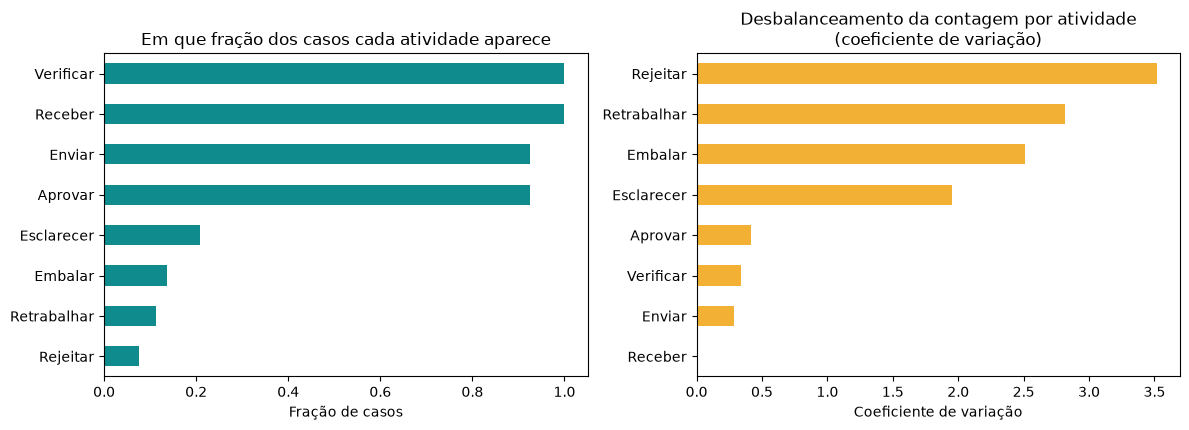


Leitura: 'Receber' e 'Verificar' aparecem em praticamente todos os casos (baixa variância, pouco poder discriminativo), enquanto 'Rejeitar', 'Retrabalhar' e 'Embalar' são raras e altamente desbalanceadas — são justamente essas que carregam o sinal que diferencia as variantes na clusterização a seguir.


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

traces_por_caso = completos.groupby("id_caso")["atividade"].apply(list)
documentos = [" ".join(trace) for trace in traces_por_caso]

# lowercase=False preserva os nomes das atividades em português como estão no log (ex.: "Receber", não "receber")
vetorizador = CountVectorizer(token_pattern=r"[^ ]+", lowercase=False)
X_atividades = vetorizador.fit_transform(documentos).toarray()
colunas_atividade = vetorizador.get_feature_names_out()
vetores_atividade = pd.DataFrame(X_atividades, index=traces_por_caso.index, columns=colunas_atividade)

comprimento_trace = traces_por_caso.apply(len)
cardinalidade_trace = traces_por_caso.apply(lambda trace: len(set(trace)))
presenca_por_atividade = (vetores_atividade > 0).mean().sort_values(ascending=False)
desbalanceamento = (vetores_atividade.std() / vetores_atividade.mean().replace(0, np.nan)).sort_values(ascending=False)

print("Comprimento do trace (nº de eventos concluídos por caso):")
print(comprimento_trace.describe().round(2))
print("\nCardinalidade (nº de atividades distintas por caso):")
print(cardinalidade_trace.describe().round(2))

perfil_atividade = pd.DataFrame(
    {
        "presença_em_casos": presenca_por_atividade,
        "coef_variação_contagem": desbalanceamento.reindex(presenca_por_atividade.index),
    }
)
print("\nPerfil por atividade (presença e desbalanceamento das contagens):")
display(perfil_atividade.round(3))

print("\nVetores de encoding (bag-of-activities), amostra de 8 casos:")
print(vetores_atividade.sample(8, random_state=1))

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.4))

perfil_atividade["presença_em_casos"].sort_values().plot.barh(ax=eixos[0], color="#0F8B8D")
eixos[0].set(title="Em que fração dos casos cada atividade aparece", xlabel="Fração de casos")

perfil_atividade["coef_variação_contagem"].sort_values().plot.barh(ax=eixos[1], color="#F2B134")
eixos[1].set(title="Desbalanceamento da contagem por atividade\n(coeficiente de variação)", xlabel="Coeficiente de variação")

fig.tight_layout()
plt.show()

print(
    "\nLeitura: 'Receber' e 'Verificar' aparecem em praticamente todos os casos (baixa variância, pouco poder "
    "discriminativo), enquanto 'Rejeitar', 'Retrabalhar' e 'Embalar' são raras e altamente desbalanceadas — são "
    "justamente essas que carregam o sinal que diferencia as variantes na clusterização a seguir."
)

Adjusted Rand Index (cluster K-Means vs. caminho real): 1.000


cluster,0,1,2,3,4
caminho,,,,,
esclarecimento,50,0,0,0,0
expresso,0,0,0,0,33
normal,0,0,112,0,0
rejeição,0,0,0,18,0
retrabalho,0,27,0,0,0


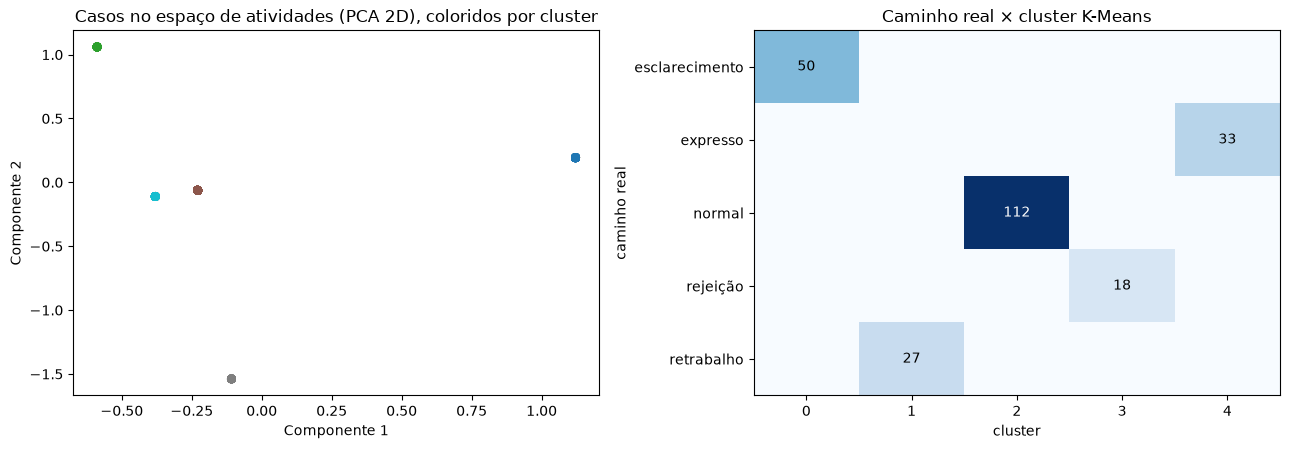

In [9]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# Reaproveita os vetores de encoding já perfilados na célula anterior (X_atividades / vetores_atividade)
N_CLUSTERS = 5  # mesmo número de caminhos conhecidos no log sintético
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=0, n_init=10).fit(X_atividades)
cluster_dos_casos = pd.Series(kmeans.labels_, index=traces_por_caso.index, name="cluster")

caminho_real = casos.set_index("id_caso").loc[traces_por_caso.index, "caminho"]
ari = adjusted_rand_score(caminho_real, cluster_dos_casos)
print(f"Adjusted Rand Index (cluster K-Means vs. caminho real): {ari:.3f}")

tabela_cruzada = pd.crosstab(caminho_real, cluster_dos_casos)
display(tabela_cruzada)

coordenadas_pca = PCA(n_components=2, random_state=0).fit_transform(X_atividades)

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

dispersao = eixos[0].scatter(coordenadas_pca[:, 0], coordenadas_pca[:, 1], c=cluster_dos_casos, cmap="tab10", s=30, alpha=0.8)
eixos[0].set(title="Casos no espaço de atividades (PCA 2D), coloridos por cluster", xlabel="Componente 1", ylabel="Componente 2")

eixos[1].imshow(tabela_cruzada, cmap="Blues", aspect="auto")
eixos[1].set_xticks(range(tabela_cruzada.shape[1]))
eixos[1].set_xticklabels(tabela_cruzada.columns)
eixos[1].set_yticks(range(tabela_cruzada.shape[0]))
eixos[1].set_yticklabels(tabela_cruzada.index)
eixos[1].set(title="Caminho real × cluster K-Means", xlabel="cluster", ylabel="caminho real")
for i in range(tabela_cruzada.shape[0]):
    for j in range(tabela_cruzada.shape[1]):
        valor = tabela_cruzada.iloc[i, j]
        if valor:
            eixos[1].text(j, i, str(valor), ha="center", va="center", color="white" if valor > 60 else "black")

fig.tight_layout()
plt.show()

## 7. Explicando as variantes: um DFG por cluster

A clusterização (ARI ≈ 1.0) redescobriu com sucesso os 5 padrões de caminho. Agora renderizamos um **DFG específico de cada cluster** para explicar visualmente o que diferencia cada variante — por exemplo, qual cluster tem o laço de retrabalho, qual tem a repetição de esclarecimento e qual termina em rejeição.

--- Cluster 0 — 50 casos — caminho predominante: 'esclarecimento' ---


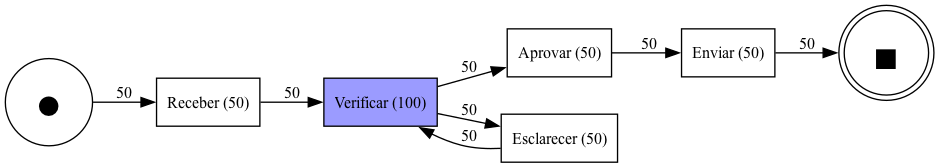

--- Cluster 1 — 27 casos — caminho predominante: 'retrabalho' ---


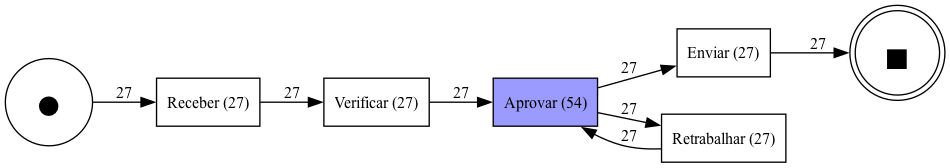

--- Cluster 2 — 112 casos — caminho predominante: 'normal' ---


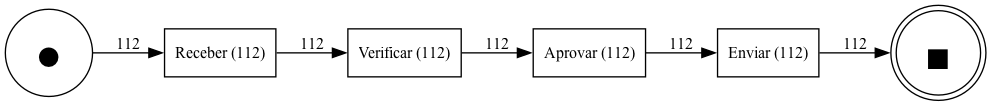

--- Cluster 3 — 18 casos — caminho predominante: 'rejeição' ---


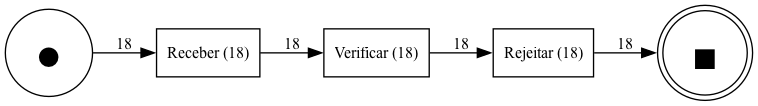

--- Cluster 4 — 33 casos — caminho predominante: 'expresso' ---


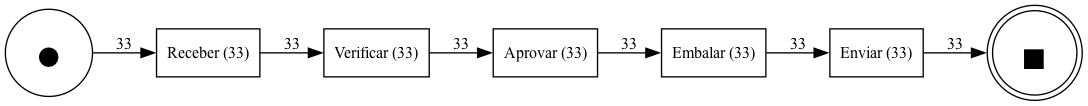

In [10]:
completos_com_cluster = completos.merge(cluster_dos_casos, left_on="id_caso", right_index=True)

for cluster_id in sorted(completos_com_cluster["cluster"].unique()):
    subconjunto = completos_com_cluster[completos_com_cluster["cluster"] == cluster_id]
    n_casos = subconjunto["id_caso"].nunique()
    caminho_predominante = casos.set_index("id_caso").loc[subconjunto["id_caso"].unique(), "caminho"].mode().iloc[0]

    log_cluster = pm4py.format_dataframe(
        subconjunto.copy(), case_id="id_caso", activity_key="atividade", timestamp_key="carimbo_tempo"
    )
    dfg_cluster, inicios_cluster, fins_cluster = pm4py.discover_dfg(log_cluster)

    caminho_imagem = pasta_saida / f"dfg_cluster_{cluster_id}.png"
    pm4py.save_vis_dfg(dfg_cluster, inicios_cluster, fins_cluster, str(caminho_imagem))

    print(f"--- Cluster {cluster_id} — {n_casos} casos — caminho predominante: '{caminho_predominante}' ---")
    display(Image(filename=str(caminho_imagem)))

## 8. Aprimoramento de processo (process enhancement)

Conectamos tempo de serviço por atividade, tempo de ciclo por caso, retrabalho e transferências entre papéis (*handovers*) — pistas para melhoria, não explicações causais automáticas.

,eventos,duracao_mediana,duracao_p90
atividade,,,
Retrabalhar,27,6.87,11.75
Esclarecer,50,5.70,8.29
Enviar,222,2.89,4.40
Embalar,33,1.60,2.66
Verificar,290,1.33,2.03
Aprovar,249,0.82,1.28
Rejeitar,18,0.41,0.59
Receber,240,0.31,0.47


,origem,destino,contagem
0,Vendas,Risco,290
1,Risco,Risco,240
2,Risco,Logística,189
3,Risco,Vendas,50
4,Risco,Armazém,33
5,Armazém,Logística,33
6,Risco,Qualidade,27
7,Qualidade,Risco,27


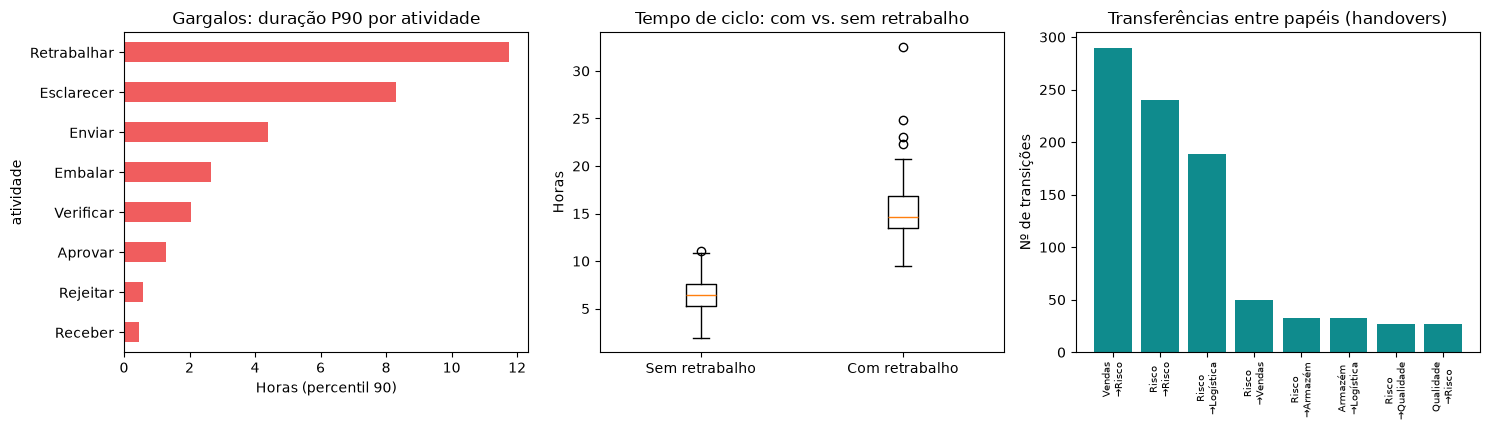

Achado preliminar: casos com retrabalho (laço Aprovar→Retrabalhar→Aprovar) têm tempo de ciclo mediano de 14.6h contra 6.4h nos casos sem retrabalho — um indício, não uma prova causal, de que reduzir o retrabalho é uma alavanca de melhoria a investigar.


In [11]:
from collections import Counter

PAPEL_POR_ATIVIDADE = {
    "Receber": "Vendas",
    "Verificar": "Risco",
    "Esclarecer": "Vendas",
    "Aprovar": "Risco",
    "Rejeitar": "Risco",
    "Embalar": "Armazém",
    "Retrabalhar": "Qualidade",
    "Enviar": "Logística",
}
completos["papel"] = completos["atividade"].map(PAPEL_POR_ATIVIDADE)
completos["proximo_papel"] = completos.groupby("id_caso")["papel"].shift(-1)

estatisticas_atividade = (
    completos.groupby("atividade")
    .agg(
        eventos=("atividade", "size"),
        duracao_mediana=("duracao_horas", "median"),
        duracao_p90=("duracao_horas", lambda serie: serie.quantile(0.9)),
    )
    .sort_values("duracao_p90", ascending=False)
)

transferencias = Counter(
    zip(
        completos.loc[completos["proximo_papel"].notna(), "papel"],
        completos.loc[completos["proximo_papel"].notna(), "proximo_papel"],
    )
)
tabela_transferencias = pd.DataFrame(
    [{"origem": origem, "destino": destino, "contagem": contagem} for (origem, destino), contagem in transferencias.most_common()]
)

casos["retrabalho"] = completos.groupby("id_caso")["atividade"].apply(lambda v: int(v.duplicated().sum())).reindex(casos["id_caso"]).to_numpy()

display(estatisticas_atividade.round(2))
display(tabela_transferencias)

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.4))

estatisticas_atividade["duracao_p90"].sort_values().plot.barh(ax=eixos[0], color="#F05D5E")
eixos[0].set(title="Gargalos: duração P90 por atividade", xlabel="Horas (percentil 90)")

eixos[1].boxplot(
    [casos.loc[casos["retrabalho"] == 0, "duracao_caso_horas"], casos.loc[casos["retrabalho"] > 0, "duracao_caso_horas"]],
    tick_labels=["Sem retrabalho", "Com retrabalho"],
)
eixos[1].set(title="Tempo de ciclo: com vs. sem retrabalho", ylabel="Horas")

posicoes = np.arange(len(tabela_transferencias))
eixos[2].bar(posicoes, tabela_transferencias["contagem"], color="#0F8B8D")
eixos[2].set_xticks(posicoes)
eixos[2].set_xticklabels(
    [f"{r.origem}\n→{r.destino}" for r in tabela_transferencias.itertuples()], rotation=90, fontsize=7
)
eixos[2].set(title="Transferências entre papéis (handovers)", ylabel="Nº de transições")

fig.tight_layout()
plt.show()

print(
    "Achado preliminar: casos com retrabalho (laço Aprovar→Retrabalhar→Aprovar) têm tempo de ciclo "
    f"mediano de {casos.loc[casos['retrabalho']>0,'duracao_caso_horas'].median():.1f}h contra "
    f"{casos.loc[casos['retrabalho']==0,'duracao_caso_horas'].median():.1f}h nos casos sem retrabalho — "
    "um indício, não uma prova causal, de que reduzir o retrabalho é uma alavanca de melhoria a investigar."
)

## 9. Verificação de conformidade

Comparamos cada trace observado com um pequeno conjunto de traces de referência (o comportamento "normativo" esperado), usando distância de edição como aproximação simples de custo de alinhamento — a mesma ideia da Unidade 8 do curso, aqui reimplementada em português para este tutorial.

60 de 240 casos apresentam algum desvio do conjunto de referência.


,id_caso,trace,referência_mais_próxima,custo_alinhamento,conformidade
177,C-0178,Receber → Verificar → Aprovar → Retrabalhar → ...,Receber → Verificar → Aprovar → Enviar,2,0.666667
218,C-0219,Receber → Verificar → Aprovar → Retrabalhar → ...,Receber → Verificar → Aprovar → Enviar,2,0.666667
56,C-0057,Receber → Verificar → Aprovar → Retrabalhar → ...,Receber → Verificar → Aprovar → Enviar,2,0.666667
167,C-0168,Receber → Verificar → Aprovar → Retrabalhar → ...,Receber → Verificar → Aprovar → Enviar,2,0.666667
194,C-0195,Receber → Verificar → Aprovar → Retrabalhar → ...,Receber → Verificar → Aprovar → Enviar,2,0.666667
24,C-0025,Receber → Verificar → Aprovar → Retrabalhar → ...,Receber → Verificar → Aprovar → Enviar,2,0.666667
23,C-0024,Receber → Verificar → Aprovar → Retrabalhar → ...,Receber → Verificar → Aprovar → Enviar,2,0.666667
149,C-0150,Receber → Verificar → Aprovar → Retrabalhar → ...,Receber → Verificar → Aprovar → Enviar,2,0.666667


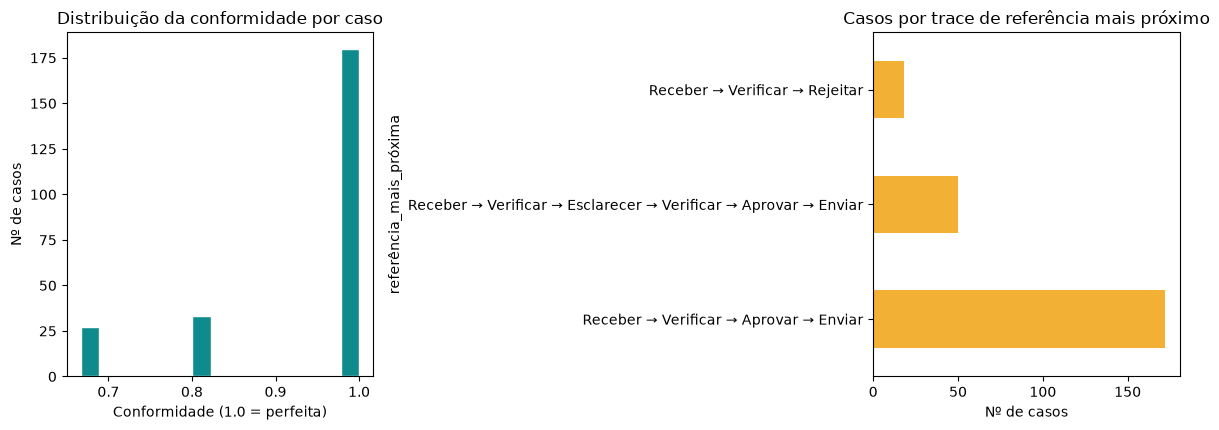

In [12]:
TRACES_REFERENCIA = (
    ("Receber", "Verificar", "Aprovar", "Enviar"),
    ("Receber", "Verificar", "Esclarecer", "Verificar", "Aprovar", "Enviar"),
    ("Receber", "Verificar", "Rejeitar"),
)


def custo_alinhamento(observado: tuple, esperado: tuple) -> int:
    """Distância de edição (Levenshtein) entre o trace observado e um trace de referência."""
    linhas, colunas = len(observado) + 1, len(esperado) + 1
    custo = [[0] * colunas for _ in range(linhas)]
    for i in range(1, linhas):
        custo[i][0] = i
    for j in range(1, colunas):
        custo[0][j] = j
    for i in range(1, linhas):
        for j in range(1, colunas):
            substituicao = custo[i - 1][j - 1] + (observado[i - 1] != esperado[j - 1])
            custo[i][j] = min(custo[i - 1][j] + 1, custo[i][j - 1] + 1, substituicao)
    return custo[-1][-1]


traces_por_caso = completos.groupby("id_caso")["atividade"].apply(tuple)
linhas_conformidade = []
for id_caso, trace in traces_por_caso.items():
    candidatos = [(custo_alinhamento(trace, referencia), referencia) for referencia in TRACES_REFERENCIA]
    custo_minimo, referencia_escolhida = min(candidatos, key=lambda item: item[0])
    denominador = max(len(trace), len(referencia_escolhida), 1)
    linhas_conformidade.append(
        {
            "id_caso": id_caso,
            "trace": " → ".join(trace),
            "referência_mais_próxima": " → ".join(referencia_escolhida),
            "custo_alinhamento": custo_minimo,
            "conformidade": 1.0 - custo_minimo / denominador,
        }
    )

conformidade_casos = pd.DataFrame(linhas_conformidade)
casos_com_desvio = conformidade_casos[conformidade_casos["custo_alinhamento"] > 0]

print(f"{len(casos_com_desvio)} de {len(conformidade_casos)} casos apresentam algum desvio do conjunto de referência.")
display(conformidade_casos.sort_values("conformidade").head(8))

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.4))

eixos[0].hist(conformidade_casos["conformidade"], bins=15, color="#0F8B8D", edgecolor="white")
eixos[0].set(title="Distribuição da conformidade por caso", xlabel="Conformidade (1.0 = perfeita)", ylabel="Nº de casos")

conformidade_casos["referência_mais_próxima"].value_counts().plot.barh(ax=eixos[1], color="#F2B134")
eixos[1].set(title="Casos por trace de referência mais próximo", xlabel="Nº de casos")

fig.tight_layout()
plt.show()

## 10. Predição da próxima atividade com `skpm`

[`skpm`](https://github.com/raseidi/skpm) é uma biblioteca de mineração de processos construída sobre o scikit-learn. Ela ainda não está publicada no PyPI (instalação via `pip install git+https://github.com/raseidi/skpm.git`), mas já expõe utilitários prontos para tarefas comuns de predição:

- `skpm.config.EventLogConfig` — configura os nomes de coluna do seu log (não é preciso renomear para o padrão XES).
- `skpm.feature_extraction.targets.next_activity` — gera o rótulo "próxima atividade" por trace, com um marcador de fim de trace.
- `skpm.sequence_encoding.Indexing` — codificação de prefixo (janela das últimas *n* atividades por posição).

Vamos usá-las com o **nosso próprio log de eventos** (traduzido) para treinar um classificador de próxima atividade.

In [13]:
# Descomente para instalar (não publicado no PyPI ainda — instalação via git):
# %pip install git+https://github.com/raseidi/skpm.git

from skpm.config import EventLogConfig as elc
from skpm.feature_extraction.targets import next_activity
from skpm.sequence_encoding import Indexing

log_skpm = completos[["id_caso", "atividade", "carimbo_tempo"]].reset_index(drop=True).copy()

# skpm nunca renomeia colunas: apontamos a configuração global para os nossos nomes em português
elc.set_global_config(case_id="id_caso", activity="atividade", timestamp="carimbo_tempo", EOT="<FIM>")

alvo_proxima_atividade = pd.Series(next_activity(log_skpm), name="proxima_atividade")

codificador_prefixo = Indexing(n=3, attributes="atividade", fill_cat_value="<FIM>")
prefixos = codificador_prefixo.fit_transform(log_skpm)

print("Exemplo de prefixos codificados (3 posições anteriores da trace):")
display(prefixos.head(8))
print("\nExemplo de rótulos (próxima atividade):")
print(alvo_proxima_atividade.head(8).tolist())

Exemplo de prefixos codificados (3 posições anteriores da trace):


,atividade_pos_1,atividade_pos_2,atividade_pos_3
0,<FIM>,<FIM>,<FIM>
1,Receber,<FIM>,<FIM>
2,Verificar,Receber,<FIM>
3,Aprovar,Verificar,Receber
4,<FIM>,<FIM>,<FIM>
5,Receber,<FIM>,<FIM>
6,Verificar,Receber,<FIM>
7,Aprovar,Verificar,Receber



Exemplo de rótulos (próxima atividade):
['Verificar', 'Aprovar', 'Enviar', '<FIM>', 'Verificar', 'Aprovar', 'Enviar', '<FIM>']


Casos de treino: 168 | Casos de teste: 72
Acurácia do modelo: 78.2%
Linha de base (sempre prever a classe majoritária): 26.3%


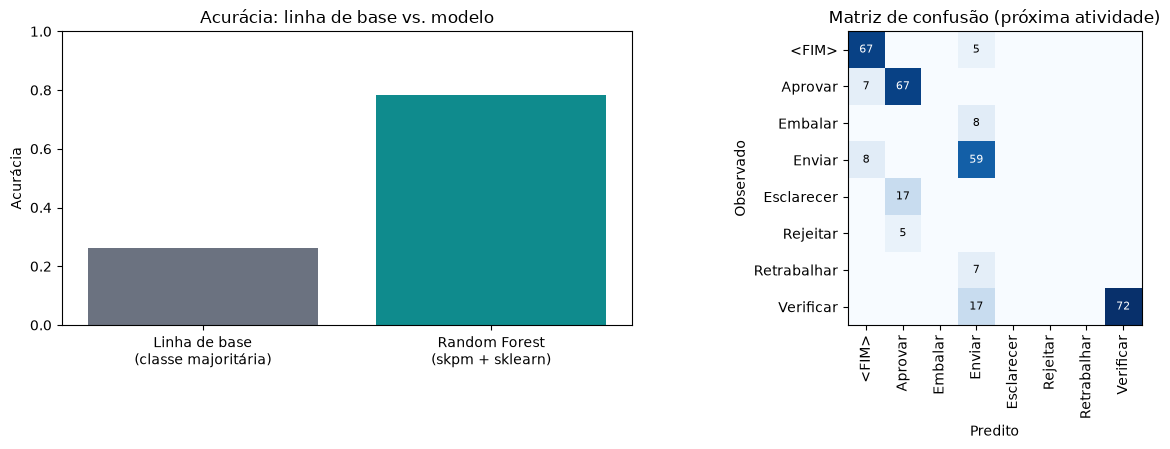

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder

# Divisão temporal por caso (casos mais antigos treinam, casos mais recentes testam) — evita vazamento, tema da Unidade 09
ids_casos_em_ordem = log_skpm.drop_duplicates("id_caso")["id_caso"].tolist()
corte = int(len(ids_casos_em_ordem) * 0.7)
casos_treino, casos_teste = set(ids_casos_em_ordem[:corte]), set(ids_casos_em_ordem[corte:])
mascara_treino = log_skpm["id_caso"].isin(casos_treino)
mascara_teste = log_skpm["id_caso"].isin(casos_teste)

codificador_onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_treino = codificador_onehot.fit_transform(prefixos[mascara_treino])
X_teste = codificador_onehot.transform(prefixos[mascara_teste])
y_treino, y_teste = alvo_proxima_atividade[mascara_treino], alvo_proxima_atividade[mascara_teste]

modelo_proxima_atividade = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
modelo_proxima_atividade.fit(X_treino, y_treino)
predito = modelo_proxima_atividade.predict(X_teste)

acuracia = accuracy_score(y_teste, predito)
linha_base_maioria = y_teste.value_counts(normalize=True).max()

print(f"Casos de treino: {len(casos_treino)} | Casos de teste: {len(casos_teste)}")
print(f"Acurácia do modelo: {acuracia:.1%}")
print(f"Linha de base (sempre prever a classe majoritária): {linha_base_maioria:.1%}")

rotulos_ordenados = sorted(alvo_proxima_atividade.unique())
matriz_confusao = confusion_matrix(y_teste, predito, labels=rotulos_ordenados)

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

eixos[0].bar(["Linha de base\n(classe majoritária)", "Random Forest\n(skpm + sklearn)"], [linha_base_maioria, acuracia], color=["#6B7280", "#0F8B8D"])
eixos[0].set(title="Acurácia: linha de base vs. modelo", ylabel="Acurácia")
eixos[0].set_ylim(0, 1)

imagem_matriz = eixos[1].imshow(matriz_confusao, cmap="Blues")
eixos[1].set_xticks(range(len(rotulos_ordenados)))
eixos[1].set_xticklabels(rotulos_ordenados, rotation=90)
eixos[1].set_yticks(range(len(rotulos_ordenados)))
eixos[1].set_yticklabels(rotulos_ordenados)
eixos[1].set(title="Matriz de confusão (próxima atividade)", xlabel="Predito", ylabel="Observado")
for i in range(matriz_confusao.shape[0]):
    for j in range(matriz_confusao.shape[1]):
        valor = matriz_confusao[i, j]
        if valor:
            eixos[1].text(j, i, str(valor), ha="center", va="center", color="white" if valor > matriz_confusao.max() / 2 else "black", fontsize=8)

fig.tight_layout()
plt.show()

## Recapitulação

Neste tutorial de ponta a ponta:

1. Carregamos e traduzimos o log de eventos sintético do Lab 01.
2. Descrevemos estatisticamente eventos, casos, atividades e traces.
3. Comparamos um candidato Pareto e um candidato dominado na detecção de variantes.
4. Descobrimos o DFG do processo completo.
5. Comparamos três algoritmos de descoberta de redes de Petri (Alpha, Heurística, Indutivo) por fitness, precisão e simplicidade, e justificamos a escolha do modelo Indutivo.
6. Redescobrimos as variantes de forma não supervisionada via profiling + encoding de fluxo de controle + K-Means (ARI ≈ 1.0 contra o rótulo real).
7. Explicamos as diferenças entre variantes usando um DFG por cluster.
8. Investigamos gargalos, retrabalho e transferências entre papéis (aprimoramento de processo).
9. Verificamos a conformidade dos casos contra um pequeno conjunto de traces de referência.
10. Treinamos um preditor de próxima atividade com `skpm` + scikit-learn, usando uma divisão temporal para evitar vazamento, superando claramente a linha de base.

Como em todo o curso: cada visualização e métrica aqui é uma peça de evidência — a explicação defensável para a decisão de processo em questão é o verdadeiro entregável, não o gráfico isoladamente.